<a href="https://colab.research.google.com/github/saad-affan12/NeuroAdaptive-UX/blob/main/student_stress_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# Student Stress Prediction
# =========================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# -------------------------
# 1. Load dataset
# -------------------------

df = pd.read_csv("/content/student_lifestyle_dataset.csv")

print(df.head())

   Student_ID  Study_Hours_Per_Day  Extracurricular_Hours_Per_Day  \
0           1                  6.9                            3.8   
1           2                  5.3                            3.5   
2           3                  5.1                            3.9   
3           4                  6.5                            2.1   
4           5                  8.1                            0.6   

   Sleep_Hours_Per_Day  Social_Hours_Per_Day  Physical_Activity_Hours_Per_Day  \
0                  8.7                   2.8                              1.8   
1                  8.0                   4.2                              3.0   
2                  9.2                   1.2                              4.6   
3                  7.2                   1.7                              6.5   
4                  6.5                   2.2                              6.6   

  Stress_Level  
0     Moderate  
1          Low  
2          Low  
3     Moderate  
4         Hig

In [ ]:
# -------------------------
# 2. Drop ID column
# -------------------------

df = df.drop("Student_ID", axis=1)

In [ ]:
# -------------------------
# 3. Encode target column
# -------------------------

le = LabelEncoder()
df["Stress_Level"] = le.fit_transform(df["Stress_Level"])

# Low=0 Moderate=1 High=2

In [ ]:
# -------------------------
# 4. Split X and y
# -------------------------

X = df.drop("Stress_Level", axis=1)
y = df["Stress_Level"]

In [ ]:
# -------------------------
# 5. Train test split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# -------------------------
# 6. Scaling
# -------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# =========================
# Logistic Regression
# =========================

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       206
           1       0.85      0.91      0.88        67
           2       0.82      0.73      0.78       127

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



In [ ]:
# =========================
# Random Forest
# =========================

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       206
           1       1.00      1.00      1.00        67
           2       1.00      1.00      1.00       127

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [ ]:
# =========================
# PCA + SVM
# =========================

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svm = SVC()

svm.fit(X_train_pca, y_train)

y_pred_svm = svm.predict(X_test_pca)

print("SVM + PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM + PCA
Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       206
           1       0.91      0.96      0.93        67
           2       0.97      0.90      0.93       127

    accuracy                           0.95       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.95      0.95      0.95       400



In [ ]:
# =========================
# XGBoost
# =========================

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       206
           1       1.00      1.00      1.00        67
           2       1.00      1.00      1.00       127

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:55:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


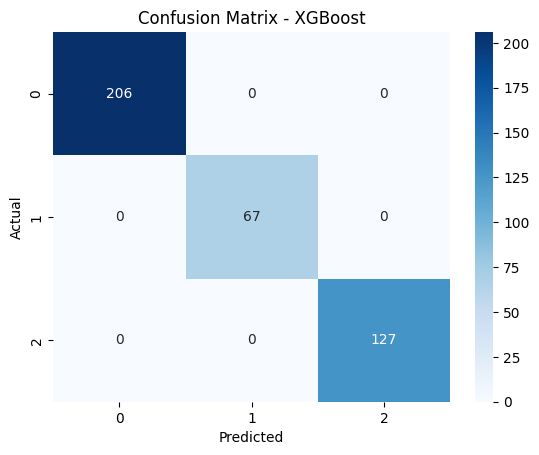

In [ ]:
# =========================
# Confusion Matrix (Best model)
# =========================

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

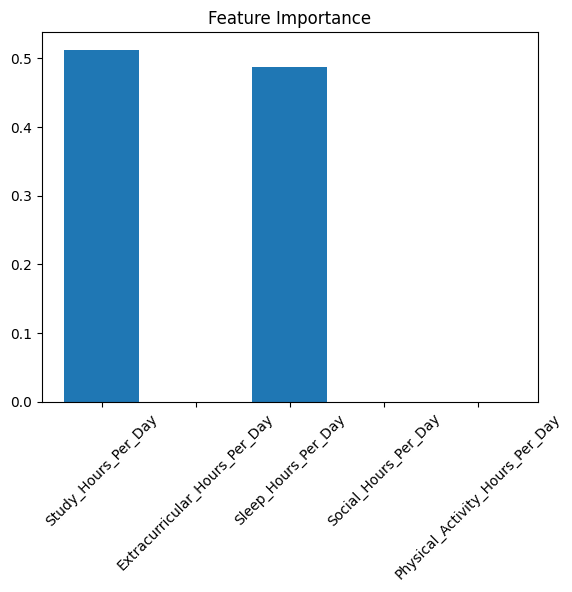

In [ ]:
# =========================
# Feature Importance
# =========================

importance = xgb.feature_importances_

plt.bar(X.columns, importance)

plt.xticks(rotation=45)
plt.title("Feature Importance")

plt.show()

In [ ]:
# =========================
# Predict new student stress (User Input)
# =========================

print("Enter student details:")

study = float(input("Study hours per day: "))
extra = float(input("Extracurricular hours per day: "))
sleep = float(input("Sleep hours per day: "))
social = float(input("Social hours per day: "))
physical = float(input("Physical activity: "))

new_data = [[
    study,
    extra,
    sleep,
    social,
    physical
]]

# convert to dataframe with same columns
new_df = pd.DataFrame(new_data, columns=X.columns)

# predict using trained XGBoost model
prediction = xgb.predict(new_df)

# convert number -> label
stress_label = le.inverse_transform(prediction)

print("Predicted Stress Level:", stress_label[0])

Enter student details:
Study hours per day: 4
Extracurricular hours per day: 3
Sleep hours per day: 5
Social hours per day: 4
Physical activity: 3
Predicted Stress Level: High


In [1]:
!pip install streamlit pyngrok xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.1 MB/s eta 0:00:00


In [2]:
%%writefile app.py
import pandas as pd
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# -------------------------
# Load dataset
# -------------------------

df = pd.read_csv("/content/student_lifestyle_dataset.csv")

df = df.drop("Student_ID", axis=1)

le = LabelEncoder()
df["Stress_Level"] = le.fit_transform(df["Stress_Level"])

X = df.drop("Stress_Level", axis=1)
y = df["Stress_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(
    use_label_encoder=False,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

# -------------------------
# Streamlit UI
# -------------------------

st.title("Student Stress Prediction")

study = st.number_input("Study hours per day", 0.0, 12.0, 5.0)
extra = st.number_input("Extracurricular hours", 0.0, 10.0, 2.0)
sleep = st.number_input("Sleep hours", 0.0, 12.0, 7.0)
social = st.number_input("Social hours", 0.0, 10.0, 3.0)
physical = st.number_input("Physical activity", 0.0, 10.0, 3.0)

if st.button("Predict Stress"):

    new_data = pd.DataFrame([[
        study,
        extra,
        sleep,
        social,
        physical
    ]], columns=X.columns)

    pred = model.predict(new_data)

    label = le.inverse_transform(pred)

    st.success(f"Predicted Stress Level: {label[0]}")

Writing app.py


In [ ]:
!streamlit run app.py --server.port 8501 --server.headless true &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.38.125:8501



In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3BX70a2R1Fkx9P5L4BEqkmLvBJs_316ghbj678WHZo421M9vS")

In [ ]:
url = ngrok.connect(8501)
print(url)